# `v71_fig1b_p38`

In [1]:
import sys
from pathlib import Path

# Ensure project root is on sys.path so local modules (common, etc.) can be imported
_project_root = str(Path(__file__).resolve().parent.parent) if "__file__" in dir() else str(Path.cwd().parent)
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)

import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
_project_root

'/Users/frohlif/Documents/projects/DeepMechanisticModels'

In [2]:
from common import EVALUATE_ALL_CSVS
from training_configuration import (
    DROPOUT_RATES,
    INFLATER_OUTPUT_REG_EPOCHS,
    L1_ENCODE_REGS,
    L1_INFLATE_OUTPUT_REGS,
    L1_INFLATE_REGS,
    L2_INFLATE_OUTPUT_REGS,
    LATENT_DIMS,
    LATENT_DIMS_BY_CONTEXT,
    NETWORK_DEPTH,
    NETWORK_DEPTH_BY_CONTEXT,
    NN_INIT_SCALES,
    OREG_ENCODE_REGS,
    OREG_INFLATE_REGS,
    RECON_REGS,
    SPARSE_THRESH_PERCS,
    SYMMETRY_REGS,
)

# Global central values for filtering - maps dataframe column names to central values
CENTRAL_VALUES = {
    "n_hidden": LATENT_DIMS["central_value"],
    "depth": NETWORK_DEPTH["central_value"],
    "dropout_rate": DROPOUT_RATES["central_value"],
    "l1reg_inflate": L1_INFLATE_REGS["central_value"],
    "oreg_inflate": OREG_INFLATE_REGS["central_value"],
    "l1reg_encode": L1_ENCODE_REGS["central_value"],
    "oreg_encode": OREG_ENCODE_REGS["central_value"],
    "l1reg_inflater_output": L1_INFLATE_OUTPUT_REGS["central_value"],
    "l2reg_inflater_output": L2_INFLATE_OUTPUT_REGS["central_value"],
    "recon_loss": RECON_REGS["central_value"],
    "symm_reg": SYMMETRY_REGS["central_value"],
    "inflater_output_reg_epoch": INFLATER_OUTPUT_REG_EPOCHS["central_value"],
    "nn_init_scale": NN_INIT_SCALES["central_value"],
    "sparse_threshold_perc": SPARSE_THRESH_PERCS["central_value"],
}

# Context-specific central-value overrides (same dicts used in generate_run_configs.py)
# Keys = param name matching CENTRAL_VALUES keys, values = {context -> central_value}
_CENTRAL_VALUE_OVERRIDES: dict[str, dict[str, int]] = {
    "n_hidden": LATENT_DIMS_BY_CONTEXT,
    "depth": NETWORK_DEPTH_BY_CONTEXT,
}


def _central_value(param: str, context: str | None = None):
    """Return the central value for *param*, respecting context-specific overrides."""
    if context is not None and param in _CENTRAL_VALUE_OVERRIDES:
        ctx_map = _CENTRAL_VALUE_OVERRIDES[param]
        if context in ctx_map:
            return ctx_map[context]
    return CENTRAL_VALUES[param]


def _normalise_expected_n(expected_n) -> set | None:
    """Convert expected_n (int, set, or None) to a set of valid counts."""
    if expected_n is None:
        return None
    if isinstance(expected_n, int):
        return {expected_n}
    return set(expected_n)


def _warn_unexpected_counts(counts, valid_ns, x_col):
    """Print a warning for (context, x_col) groups whose count is not in valid_ns."""
    if valid_ns is None:
        return
    invalid_counts = counts[~counts.isin(valid_ns)]
    if len(invalid_counts) > 0:
        print(f"WARNING: The following (context, {x_col}) combinations do not have {valid_ns} datapoints:")
        for (ctx, x_val), count in invalid_counts.items():
            print(f"  ({ctx}, {x_val}): {count} datapoints")


def filter_to_central(df, exclude_cols=None):
    """Filter dataframe to central values, respecting per-context overrides.

    For each row the expected central value depends on its *context* column
    (if present) so that e.g. multimodal rows are compared against n_hidden=6
    rather than the global default of 4.
    """
    if exclude_cols is None:
        exclude_cols = []

    has_context = "context" in df.columns
    mask = pd.Series(True, index=df.index)

    for col, global_val in CENTRAL_VALUES.items():
        if col in exclude_cols or col not in df.columns:
            continue

        if has_context and col in _CENTRAL_VALUE_OVERRIDES:
            # Build a per-row expected central value based on context
            ctx_map = _CENTRAL_VALUE_OVERRIDES[col]
            expected = df["context"].map(lambda ctx, m=ctx_map, g=global_val: m.get(ctx, g))
            mask &= df[col] == expected
        else:
            mask &= df[col] == global_val

    return df[mask]

def kruskal_wallis_groups(df, target_metric, group_metric, context_metric="context"):
    """Perform Kruskal-Wallis H-test for each context and return results."""
    results = []
    for context in df[context_metric].unique():
        context_data = df[df[context_metric] == context]
        groups = [group[target_metric].values for _, group in context_data.groupby(group_metric)]
        if len(groups) > 1:
            stat, p_value = stats.kruskal(*groups)
            print(f"Context: {context} - Kruskal-Wallis H-test: H-statistic={stat:.2f}, p-value={p_value:.4f}, significant? {p_value < 0.05}")
            results.append({"context": context, "H_statistic": stat, "p_value": p_value})
    return pd.DataFrame(results)


def plot_pvalues(df, x_col, palette, exclude_cols=None, figsize=(8, 3), alpha=0.05):
    """Plot a barplot of p-values from Kruskal-Wallis tests for each context."""
    if exclude_cols is None:
        exclude_cols = [x_col]
    elif x_col not in exclude_cols:
        exclude_cols = list(exclude_cols) + [x_col]

    filtered_df = filter_to_central(df, exclude_cols=exclude_cols)

    # Get p-values for each group
    results = []
    for group_name in palette.keys():
        group_data = filtered_df[filtered_df["context"] == group_name]
        groups = [g["rmse"].values for _, g in group_data.groupby(x_col)]
        if len(groups) > 1:
            stat, p_value = stats.kruskal(*groups)
            results.append({"group": group_name, "p_value": p_value})

    results_df = pd.DataFrame(results)

    fig, ax = plt.subplots(figsize=figsize)
    ax.bar(
        results_df["group"],
        results_df["p_value"],
        color=[palette[g] for g in results_df["group"]]
    )
    ax.axhline(y=alpha, color='red', linestyle='--', label=f'α = {alpha}')
    ax.set_ylabel("p-value")
    ax.set_xlabel("Context")
    ax.set_title(f"Kruskal-Wallis p-values for {x_col}")
    ax.set_xticks(range(len(results_df)))
    ax.set_xticklabels(results_df["group"], rotation=45, ha='right')
    ax.legend()
    plt.tight_layout()
    return fig, ax


def plot_all_hyperparameters(df, palette, hyperparams, expected_n=5, ncols=3, figsize_per_plot=(4, 3), sharey=True):
    """Create a facet grid with all hyperparameter scans.

    Args:
        df: DataFrame with data
        palette: Color palette dict mapping context names to colors
        hyperparams: List of dicts with keys 'col' (column name) and 'log_scale' (bool)
        expected_n: Expected number of datapoints per (context, x_col) combination.
            Can be an int, a set of ints, or None to skip validation.
        ncols: Number of columns in the grid
        figsize_per_plot: Size of each subplot
        sharey: If True, all subplots share the same y-axis limits
    """
    import numpy as np

    valid_ns = _normalise_expected_n(expected_n)

    nrows = int(np.ceil(len(hyperparams) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_per_plot[0] * ncols, figsize_per_plot[1] * nrows),
                             sharey=sharey)
    axes = axes.flatten()

    for idx, hp in enumerate(hyperparams):
        ax = axes[idx]
        x_col = hp['col']
        log_scale = hp.get('log_scale', False)

        # Filter to central values excluding current hyperparameter
        filtered_df = filter_to_central(df, exclude_cols=[x_col])

        # Warn (but don't filter) if counts don't match expected_n
        counts = filtered_df.groupby(["context", x_col]).size()
        _warn_unexpected_counts(counts, valid_ns, x_col)

        # Handle log scale with zero values
        if log_scale:
            zero_mask = filtered_df[x_col] == 0
            nonzero_df = filtered_df[~zero_mask]
            zero_df = filtered_df[zero_mask]
        else:
            nonzero_df = filtered_df
            zero_df = None

        sns.lineplot(
            data=nonzero_df,
            x=x_col,
            y="rmse",
            hue="context",
            hue_order=palette.keys(),
            palette=palette,
            marker='o',
            estimator='median',
            ax=ax,
            legend=(idx == 0)  # Only show legend on first plot
        )

        if log_scale:
            ax.set_xscale('log')
            # Plot zero values as horizontal lines
            if zero_df is not None and len(zero_df) > 0:
                for group_name, color in palette.items():
                    group_zero = zero_df[zero_df["context"] == group_name]
                    if len(group_zero) > 0:
                        mean_rmse = group_zero["rmse"].mean()
                        ax.axhline(y=mean_rmse, color=color, linestyle='--', alpha=0.5)

        # Add vertical line at central value — use per-context lines if overrides exist
        if x_col in CENTRAL_VALUES:
            if x_col in _CENTRAL_VALUE_OVERRIDES:
                # Draw one vertical line per context that has an override
                drawn_globals = False
                for context_name, color in palette.items():
                    cv = _central_value(x_col, context_name)
                    if cv != 0 or not log_scale:
                        ax.axvline(x=cv, color=color, linestyle=':', alpha=0.7)
                    # Also draw horizontal RMSE line at that context's central value
                    context_central = nonzero_df[(nonzero_df["context"] == context_name) & (nonzero_df[x_col] == cv)]
                    if len(context_central) > 0:
                        context_rmse = context_central["rmse"].mean()
                        ax.axhline(y=context_rmse, color=color, linestyle=':', alpha=0.5)
            else:
                central_val = CENTRAL_VALUES[x_col]
                if central_val != 0 or not log_scale:  # Don't plot zero on log scale
                    ax.axvline(x=central_val, color='gray', linestyle=':', alpha=0.7, label='central')
                    # Add horizontal line at RMSE value for central value (one per context)
                    central_data = nonzero_df[nonzero_df[x_col] == central_val]
                    for context_name, color in palette.items():
                        context_central = central_data[central_data["context"] == context_name]
                        if len(context_central) > 0:
                            context_rmse = context_central["rmse"].mean()
                            ax.axhline(y=context_rmse, color=color, linestyle=':', alpha=0.5)

        ax.set_xlabel(x_col)
        ax.set_ylabel("RMSE")
        ax.set_title(x_col)

    # Hide unused subplots
    for idx in range(len(hyperparams), len(axes)):
        axes[idx].set_visible(False)

    # Move legend outside
    if len(hyperparams) > 0:
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, title="Context", loc='upper right', bbox_to_anchor=(1.12, 0.98))
        axes[0].get_legend().remove()

    plt.tight_layout()
    return fig, axes


model = "EGFR_MAPK__logobs"
data = "dream_cytof"
filename = "evaluate_all_figure1b"

df = pd.read_csv(EVALUATE_ALL_CSVS.format(model=model, data=data, filename=filename), index_col=0)

In [3]:
val_df = df[(df.dataset == "val") & (df.ref == "DMM")]
val_df.features.fillna("None", inplace=True)
val_df = val_df.groupby(["context", "features", "model", "samples"] + [key for key in CENTRAL_VALUES if key in val_df.columns]).rmse.median().reset_index()

  (MOSA, 1.0): 3 datapoints
  (MOSA, 2.0): 3 datapoints
  (MOSA, 3.0): 3 datapoints
  (MOSA, 4.0): 3 datapoints
  (MOSA, 5.0): 3 datapoints
  (MOSA, 6.0): 3 datapoints
  (MOSA, 7.0): 3 datapoints
  (MOSA, 8.0): 3 datapoints
  (cytof_init, 1.0): 5 datapoints
  (cytof_init, 2.0): 5 datapoints
  (cytof_init, 3.0): 5 datapoints
  (cytof_init, 4.0): 5 datapoints
  (cytof_init, 5.0): 5 datapoints
  (cytof_init, 6.0): 5 datapoints
  (cytof_init, 7.0): 5 datapoints
  (cytof_init, 8.0): 5 datapoints
  (multimodal, 1.0): 5 datapoints
  (multimodal, 2.0): 5 datapoints
  (multimodal, 3.0): 5 datapoints
  (multimodal, 4.0): 5 datapoints
  (multimodal, 5.0): 5 datapoints
  (multimodal, 6.0): 5 datapoints
  (multimodal, 7.0): 5 datapoints
  (multimodal, 8.0): 5 datapoints
  (proteomics, 1.0): 5 datapoints
  (proteomics, 2.0): 5 datapoints
  (proteomics, 3.0): 5 datapoints
  (proteomics, 4.0): 5 datapoints
  (proteomics, 5.0): 5 datapoints
  (proteomics, 6.0): 5 datapoints
  (proteomics, 7.0): 5 datap

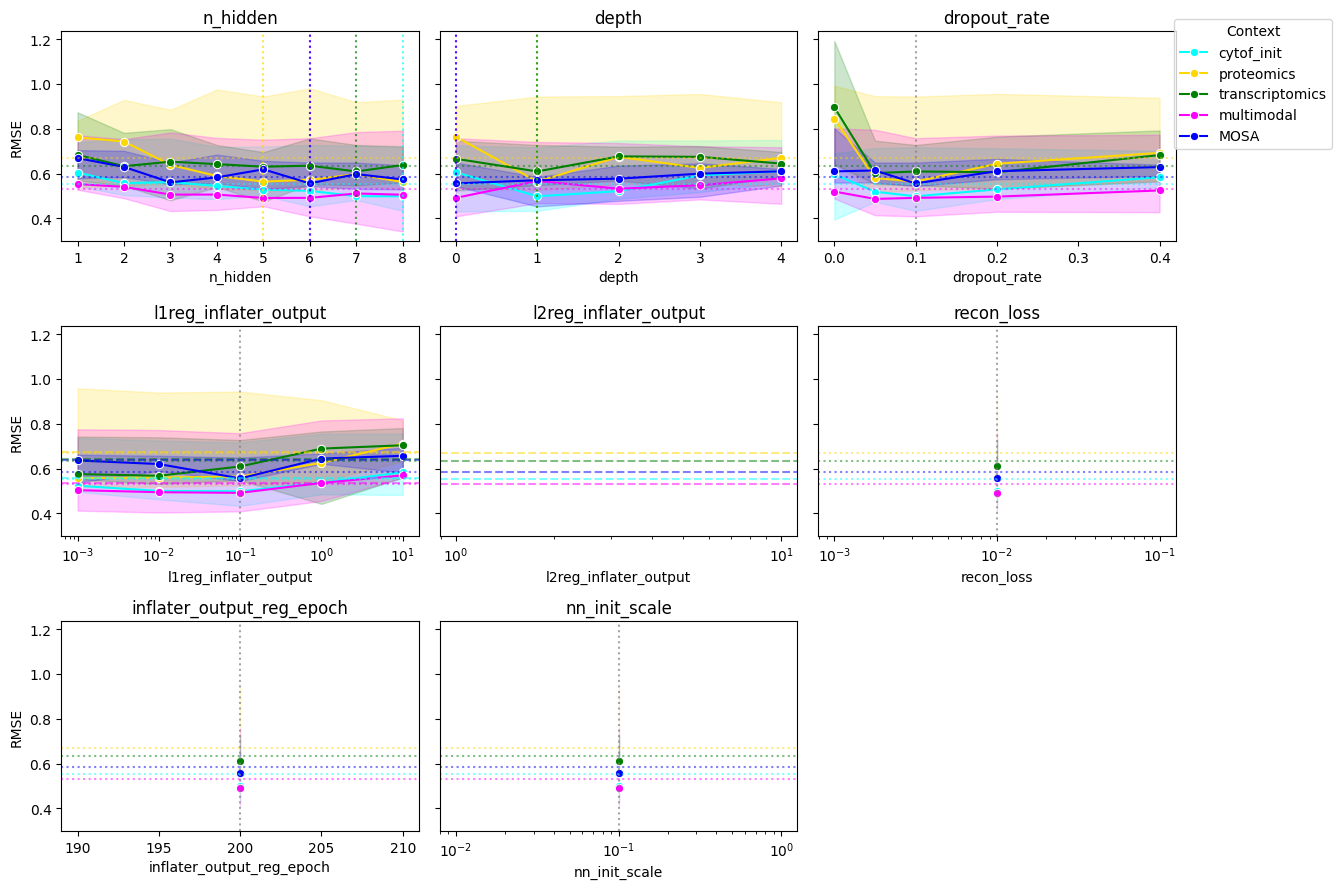

In [4]:
palette = {
    "cytof_init": "cyan",
    "proteomics": "gold",
    "transcriptomics": "green",
    "multimodal": "magenta",
    "MOSA": "blue",
}

# Define hyperparameters to plot
HYPERPARAMS_TO_PLOT = [
    {"col": "n_hidden", "log_scale": False},
    {"col": "depth", "log_scale": False},
    {"col": "dropout_rate", "log_scale": False},
    # {"col": "l1reg_inflate", "log_scale": True},
    # {"col": "oreg_inflate", "log_scale": True},
    # {"col": "l1reg_encode", "log_scale": True},
    # {"col": "oreg_encode", "log_scale": True},
    {"col": "l1reg_inflater_output", "log_scale": True},
    {"col": "l2reg_inflater_output", "log_scale": True},
    {"col": "recon_loss", "log_scale": True},
    # {"col": "symm_reg", "log_scale": True},
    # {"col": "median_reg", "log_scale": True},
    {"col": "inflater_output_reg_epoch", "log_scale": False},
    {"col": "nn_init_scale", "log_scale": True},
]

plot_all_hyperparameters(val_df, palette, HYPERPARAMS_TO_PLOT, expected_n={30, 50}, ncols=3);

Index(['BT20', 'HCC1500', 'HCC2185', 'MCF7', 'UACC3199'], dtype='str', name='samples')
Index(['BT20', 'HCC1500', 'HCC2185', 'MCF7', 'UACC3199'], dtype='str', name='samples')
Index(['BT20', 'HCC1500', 'HCC2185', 'MCF7', 'UACC3199'], dtype='str', name='samples')
Index(['BT20', 'HCC1500', 'HCC2185', 'MCF7', 'UACC3199'], dtype='str', name='samples')
Index(['BT20', 'HCC1500', 'HCC2185', 'MCF7', 'UACC3199'], dtype='str', name='samples')
Index(['BT20', 'HCC1500', 'HCC2185', 'MCF7', 'UACC3199'], dtype='str', name='samples')
Index(['BT20', 'HCC1500', 'MCF7'], dtype='str', name='samples')
Index(['BT20', 'HCC1500', 'MCF7'], dtype='str', name='samples')
Index(['BT20', 'HCC1500', 'HCC2185', 'MCF7', 'UACC3199'], dtype='str', name='samples')
Index(['BT20', 'HCC1500', 'HCC2185', 'MCF7', 'UACC3199'], dtype='str', name='samples')
Index(['BT20', 'HCC1500', 'HCC2185', 'MCF7', 'UACC3199'], dtype='str', name='samples')
Index(['BT20', 'HCC1500', 'HCC2185', 'MCF7', 'UACC3199'], dtype='str', name='samples')
In

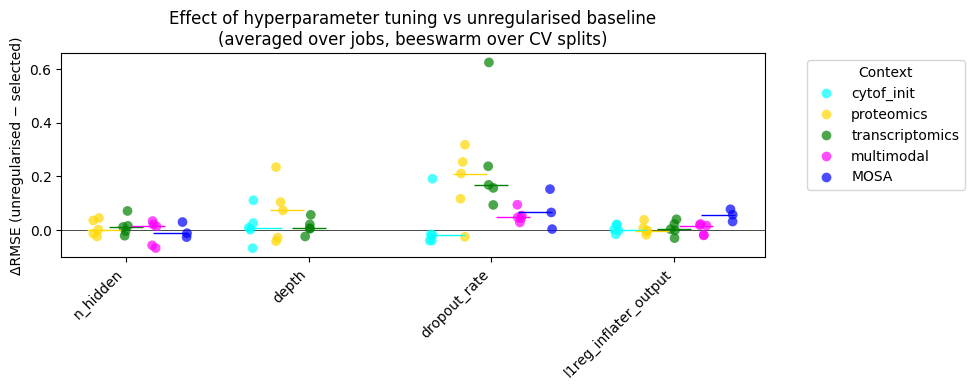

In [8]:
import numpy as np

# Baseline ("unregularised") values for each hyperparameter
_BASELINE_VALUES = {
    "n_hidden": 8,
    "depth": 0,
    "dropout_rate": 0,
    "l1reg_inflater_output": 0,
    "l2reg_inflater_output": 0,
    "recon_loss": 0,
}

records = []
for hp in HYPERPARAMS_TO_PLOT:
    x_col = hp["col"]
    baseline_val = _BASELINE_VALUES.get(x_col)
    if baseline_val is None:
        continue

    filtered_df = filter_to_central(val_df, exclude_cols=[x_col])

    for context_name in palette:
        central_val = _central_value(x_col, context_name)
        if baseline_val == central_val:
            continue

        ctx_data = filtered_df[filtered_df["context"] == context_name]

        # Average RMSE over jobs per (samples, x_col value)
        bl = (ctx_data[ctx_data[x_col] == baseline_val]
              .groupby("samples")["rmse"].mean())
        ct = (ctx_data[ctx_data[x_col] == central_val]
              .groupby("samples")["rmse"].mean())
        
        print(bl.index)
        print(ct.index)

        # Paired delta per CV split
        common_splits = bl.index.intersection(ct.index)
        if len(common_splits) == 0:
            continue

        deltas = bl.loc[common_splits] - ct.loc[common_splits]
        for split, delta in deltas.items():
            records.append({
                "hyperparameter": x_col,
                "context": context_name,
                "split": split,
                "delta_rmse": delta,
            })

delta_df = pd.DataFrame(records)

# --- Beeswarm (stripplot) over CV splits, with median ---
fig, ax = plt.subplots(figsize=(10, 4))
sns.stripplot(
    data=delta_df,
    x="hyperparameter",
    y="delta_rmse",
    hue="context",
    hue_order=palette.keys(),
    palette=palette,
    dodge=True,
    jitter=True,
    ax=ax,
    size=7,
    alpha=0.7,
)
# Overlay median for each group
for i, hp_name in enumerate(delta_df["hyperparameter"].unique()):
    for j, ctx in enumerate(palette):
        group = delta_df[(delta_df["hyperparameter"] == hp_name) & (delta_df["context"] == ctx)]["delta_rmse"]
        if len(group) > 0:
            median = group.median()
            ax.plot(i + (j - 2) * 0.12, median, marker="_", color=palette[ctx], markersize=24, linewidth=3, zorder=10)
ax.axhline(y=0, color="black", linewidth=0.5)
ax.set_ylabel("ΔRMSE (unregularised − selected)")
ax.set_xlabel("")
ax.set_title("Effect of hyperparameter tuning vs unregularised baseline\n(averaged over jobs, beeswarm over CV splits)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.legend(title="Context", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

# --- Wilcoxon signed-rank test over splits (H0: median delta = 0) ---
print("\nWilcoxon signed-rank test over CV splits (H0: ΔRMSE = 0, job-averaged):")
print(f"{'hyperparameter':<30} {'context':<18} {'n':>4}  {'median ΔRMSE':>12}  {'p-value':>10}  sig?")
print("-" * 90)
for hp_name in delta_df["hyperparameter"].unique():
    for ctx in palette:
        subset = delta_df[(delta_df["hyperparameter"] == hp_name) & (delta_df["context"] == ctx)]["delta_rmse"]
        if len(subset) < 5:
            continue
        stat, p = stats.wilcoxon(subset)
        sig = "*" if p < 0.05 else ""
        if p < 0.01:
            sig = "**"
        if p < 0.001:
            sig = "***"
        print(f"{hp_name:<30} {ctx:<18} {len(subset):>4}  {subset.median():>12.4f}  {p:>10.4g}  {sig}")

In [6]:
val_df.columns

Index(['context', 'features', 'model', 'samples', 'n_hidden', 'depth',
       'dropout_rate', 'l1reg_inflate', 'oreg_inflate', 'l1reg_encode',
       'oreg_encode', 'l1reg_inflater_output', 'l2reg_inflater_output',
       'recon_loss', 'symm_reg', 'inflater_output_reg_epoch', 'nn_init_scale',
       'rmse'],
      dtype='str')

## Individual plots